In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[2]
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
from src.utils.metrics import (
    sharpe_ratio,
    max_drawdown,
    annualized_return,
    annualized_volatility,
)

from src.risk.drawdown import (
    compute_drawdown,
    drawdown_exposure_smooth,
    apply_exposure_to_return
)


/Users/rawls/quant-lab


Does it only work for one parameter set? --> overfitting detection

Does it survive different clipping ranges? --> stability

Does behavior persist under different DD sensitivity? --> robustness

Does improvement collapse easily? --> fragility


In [8]:
df = pd.read_csv(
    PROJECT_ROOT /
    "experiments/completed/exp_005_risk_engine_final/final_returns_v2_with_dates.csv"
)

df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date")

ret = df["returns"]

eq = (1 + ret).cumprod()

In [10]:
dd = compute_drawdown(eq)

rolling_vol = (
    ret
    .rolling(252)
    .std()
    * np.sqrt(252)
)

multiplier = (
    rolling_vol / rolling_vol.mean()
) ** 0.5

multiplier = multiplier.clip(0.7, 1.3)

**Parameter Sensitivity**

In [11]:
k_values = [1, 2, 3, 5]

robustness_results = []

for k in k_values:

    dd_exp = drawdown_exposure_smooth(
        dd,
        floor=0.6,
        k=k
    )

    multiplier_test = (
        multiplier * dd_exp
    ).clip(0.3, 1.5)

    ret_test = apply_exposure_to_return(
        ret,
        multiplier_test
    )

    eq_test = (1 + ret_test).cumprod()

    robustness_results.append({
        "k": k,
        "Sharpe": sharpe_ratio(ret_test),
        "MDD": max_drawdown(eq_test),
        "CAGR": annualized_return(ret_test),
        "Calmar": (
            annualized_return(ret_test)
            / abs(max_drawdown(eq_test))
        )
    })

In [13]:
robustness_df = pd.DataFrame(
    robustness_results
).round(3)

robustness_df

,k,Sharpe,MDD,CAGR,Calmar
0,1,2.087,-0.339,0.374,1.105
1,2,2.117,-0.324,0.374,1.153
2,3,2.143,-0.312,0.373,1.195
3,5,2.187,-0.294,0.372,1.265


The robustness analysis showed that the adaptive overlay framework exhibited stable behavior across multiple drawdown sensitivity parameters rather than relying on a single narrowly optimized configuration. As the drawdown aggressiveness parameter k increased, Sharpe ratio, maximum drawdown, and Calmar ratio improved gradually while CAGR remained remarkably stable, indicating that stronger drawdown-based exposure compression reduced portfolio risk without materially damaging long-term compounding. Importantly, performance did not collapse under nearby parameter variations, which reduces concerns about severe parameter overfitting and suggests that the overlay behavior may reflect a more persistent structural effect rather than a fragile historical artifact. The results imply that the adaptive overlay is potentially suppressing harmful risk periods while preserving much of the underlying strategy’s return generation. Although this does not prove future robustness or eliminate overfitting risk entirely, the stability of results across parameter ranges provides encouraging evidence that the overlay framework may generalize more reliably than a narrowly tuned configuration.

**Robustness Check**

In [24]:
# clip ranges

clip_ranges = [
    (0.5, 1.2),
    (0.5, 1.3),
    (0.3, 1.5),
    (0.2, 2.0),
    (0.6, 1.2),
    (0.7, 1.1),
    (0.8, 1.0),
    (1.0, 1.0),
]

clip_results = []

for lower, upper in clip_ranges:

    dd_exp = drawdown_exposure_smooth(
        dd,
        floor=0.6,
        k=5
    )

    multiplier_test = (
        multiplier * dd_exp
    ).clip(lower, upper)

    ret_test = apply_exposure_to_return(
        ret,
        multiplier_test
    )

    eq_test = (1 + ret_test).cumprod()

    clip_results.append({
        "clip": f"{lower}-{upper}",
        "Sharpe": sharpe_ratio(ret_test),
        "MDD": max_drawdown(eq_test),
        "CAGR": annualized_return(ret_test),
        "Calmar": (
            annualized_return(ret_test)
            / abs(max_drawdown(eq_test))
        ),
        "Avg Exposure": multiplier_test.mean(),
        "Min Exposure": multiplier_test.min(),
        "Max Exposure": multiplier_test.max()
    })

In [25]:
clip_df = pd.DataFrame(
    clip_results
).round(3)

clip_df

,clip,Sharpe,MDD,CAGR,Calmar,Avg Exposure,Min Exposure,Max Exposure
0,0.5-1.2,2.189,-0.294,0.369,1.255,0.816,0.500,1.2
1,0.5-1.3,2.187,-0.294,0.372,1.265,0.819,0.500,1.3
2,0.3-1.5,2.187,-0.294,0.372,1.265,0.819,0.499,1.3
3,0.2-2.0,2.187,-0.294,0.372,1.265,0.819,0.499,1.3
4,0.6-1.2,2.190,-0.294,0.369,1.257,0.824,0.600,1.2
5,0.7-1.1,2.197,-0.296,0.363,1.227,0.836,0.700,1.1
6,0.8-1.0,2.189,-0.305,0.353,1.160,0.862,0.800,1.0
7,1.0-1.0,2.151,-0.343,0.375,1.094,1.000,1.000,1.0


In [26]:
(multiplier * dd_exp).describe()

count    2307.000000
mean        0.819147
std         0.188892
min         0.499355
25%         0.677266
50%         0.809776
75%         0.925816
max         1.300000
Name: returns, dtype: float64

In [27]:
print((multiplier * dd_exp).min())
print((multiplier * dd_exp).max())

0.49935513536279214
1.3


This robustness analysis suggests that the overlay framework is structurally stable across a broad range of exposure constraints. Performance metrics changed gradually rather than collapsing under tighter clipping ranges, indicating that the overlay behavior is not highly dependent on narrowly optimized leverage boundaries. The adaptive exposure system continued to maintain strong Sharpe and Calmar characteristics even under significantly constrained exposure ranges, while the constant-exposure control case (1.0–1.0) confirmed that the overlay contributed meaningful drawdown reduction relative to the baseline fully invested portfolio. Importantly, the results suggest that the overlay’s primary benefit arises from controlled downside exposure suppression rather than aggressive leverage amplification, which is a healthier and more believable source of portfolio improvement. Overall, the clipping sensitivity results reduce concerns about fragile parameter engineering and provide encouraging evidence that the adaptive overlay logic may capture a persistent structural effect rather than relying on highly specific exposure thresholds.

**Drawdown Sensitivity**

In [28]:
floor_values = [0.3, 0.5, 0.6, 0.7, 0.9]
k = 5

floor_results = []
for floor in floor_values:

    dd_exp = drawdown_exposure_smooth(
        dd,
        floor=floor,
        k=5
    )

    multiplier_test = (
        multiplier * dd_exp
    ).clip(0.5, 1.3)

    ret_test = apply_exposure_to_return(
        ret,
        multiplier_test
    )

    eq_test = (1 + ret_test).cumprod()

    floor_results.append({
        "floor": floor,
        "Sharpe": sharpe_ratio(ret_test),
        "MDD": max_drawdown(eq_test),
        "CAGR": annualized_return(ret_test),
        "Calmar": annualized_return(ret_test)
        / abs(max_drawdown(eq_test)),
        "Avg Exposure": multiplier_test.mean(),
        "Min Exposure": multiplier_test.min(),
        "Max Exposure": multiplier_test.max()
    })

In [29]:
floor_df = pd.DataFrame(
    floor_results
).round(3)

floor_df

,floor,Sharpe,MDD,CAGR,Calmar,Avg Exposure,Min Exposure,Max Exposure
0,0.3,2.292,-0.248,0.372,1.499,0.714,0.50,1.3
1,0.5,2.221,-0.277,0.371,1.339,0.780,0.50,1.3
2,0.6,2.187,-0.294,0.372,1.265,0.819,0.50,1.3
3,0.7,2.153,-0.310,0.373,1.202,0.860,0.55,1.3
4,0.9,2.086,-0.341,0.374,1.096,0.943,0.65,1.3


The drawdown sensitivity robustness analysis showed highly stable and monotonic behavior across a broad range of minimum exposure floors. Allowing the overlay to become more defensive during stress periods consistently improved Sharpe ratio, maximum drawdown, and Calmar ratio while leaving CAGR nearly unchanged. Lower exposure floors enabled stronger downside suppression and materially reduced portfolio drawdowns without significantly impairing long-term compounding, suggesting that the adaptive overlay may be selectively removing disproportionately harmful risk periods rather than simply reducing exposure indiscriminately. Importantly, the parameter responses changed smoothly and coherently across the tested range, with no evidence of abrupt instability or performance collapse, which reduces concerns about fragile parameter tuning or severe overfitting. Overall, the results provide encouraging evidence that the overlay framework exhibits structurally stable behavior and may genuinely improve portfolio efficiency through adaptive risk management rather than relying on narrowly optimized configurations.

**Ablation Test - Drawdown Only**

Note:
The ablation analysis below uses the later robustness configuration
(floor=0.3, k=5, clip=0.5–1.3), which differs from earlier
overlay experiments. Therefore, absolute metric values are not
directly comparable to earlier sections. The purpose of this
analysis is structural component attribution rather than exact
performance replication.

In [ ]:
dd_only_results = []

dd_exp = drawdown_exposure_smooth(
    dd,
    floor=0.3,
    k=5
)

ret_dd_only = apply_exposure_to_return(
    ret,
    dd_exp
)

eq_dd_only = (
    1 + ret_dd_only
).cumprod()

        


In [35]:
# from previous notebook

vol_only_multiplier = (
    rolling_vol / rolling_vol.mean()
) ** 0.5

vol_only_multiplier = vol_only_multiplier.clip(0.5, 1.3)

ret_vol_only = apply_exposure_to_return(
    ret,
    vol_only_multiplier
)

eq_vol_only = (
    1 + ret_vol_only
).cumprod()

In [33]:
# from previous notebook

combined_multiplier = (
    multiplier * dd_exp
).clip(0.5, 1.3)

ret_combined = apply_exposure_to_return(
    ret,
    combined_multiplier
)

eq_combined = (
    1 + ret_combined
).cumprod()

In [37]:
ablation_df = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Sharpe": sharpe_ratio(ret),
        "MDD": max_drawdown(eq),
        "CAGR": annualized_return(ret),
        "Calmar": (
            annualized_return(ret)
            / abs(max_drawdown(eq))
        )
    },

    {
        "Strategy": "Vol Only",
        "Sharpe": sharpe_ratio(ret_vol_only),
        "MDD": max_drawdown(eq_vol_only),
        "CAGR": annualized_return(ret_vol_only),
        "Calmar": (
            annualized_return(ret_vol_only)
            / abs(max_drawdown(eq_vol_only))
        )
    },

    {
        "Strategy": "DD Only",
        "Sharpe": sharpe_ratio(ret_dd_only),
        "MDD": max_drawdown(eq_dd_only),
        "CAGR": annualized_return(ret_dd_only),
        "Calmar": (
            annualized_return(ret_dd_only)
            / abs(max_drawdown(eq_dd_only))
        )
    },

    {
        "Strategy": "Combined",
        "Sharpe": sharpe_ratio(ret_combined),
        "MDD": max_drawdown(eq_combined),
        "CAGR": annualized_return(ret_combined),
        "Calmar": (
            annualized_return(ret_combined)
            / abs(max_drawdown(eq_combined))
        )
    }

]).round(3)

ablation_df

,Strategy,Sharpe,MDD,CAGR,Calmar
0,Baseline,2.151,-0.343,0.375,1.094
1,Vol Only,2.050,-0.356,0.374,1.050
2,DD Only,2.398,-0.232,0.362,1.561
3,Combined,2.292,-0.248,0.372,1.499


The ablation analysis revealed that the majority of the overlay improvement appears to originate from the drawdown-based adaptive exposure mechanism rather than the volatility-scaling component. Under the tested robustness configuration, the volatility-only overlay slightly underperformed the baseline portfolio, while the drawdown-only overlay produced substantial improvements in Sharpe ratio, maximum drawdown, and Calmar ratio with only minimal impact on CAGR. Interestingly, the combined overlay still improved meaningfully over the baseline but underperformed the drawdown-only system, suggesting that the volatility overlay may partially dilute or interfere with the cleaner portfolio-stress signal captured by the drawdown mechanism. These findings indicate that adaptive exposure control based on realized portfolio stress may be more aligned with the true failure structure of the strategy than market volatility scaling alone, and they highlight the importance of component-level ablation analysis when evaluating adaptive portfolio control systems.

**Different Rolling Windows Test**

In [38]:
windows_values = [63, 126, 252, 504]

window_results = []

floor = 0.3
k = 5
lower = 0.5
upper = 1.3

for window in windows_values:

    rolling_vol_test = (
        ret
        .rolling(window)
        .std()
        * np.sqrt(252)
    )

    multiplier_test = (
        (rolling_vol_test / rolling_vol_test.mean()) ** 0.5
    ).clip(0.7, 1.3)

    dd_exp = drawdown_exposure_smooth(
        dd,
        floor=floor,
        k=k
    )

    combined_multiplier = (
        multiplier_test ** dd_exp
    ).clip(lower, upper)

    ret_test = apply_exposure_to_return(
        ret,
        combined_multiplier
    )

    eq_test = (1 + ret_test).cumprod()

    window_results.append({
        "window": window,
        "Sharpe": sharpe_ratio(ret_test),
        "MDD": max_drawdown(eq_test),
        "CAGR": annualized_return(ret_test),
        "Calmar": annualized_return(ret_test) / abs(max_drawdown(eq_test)),
        "Avg Exposure": combined_multiplier.mean(),
        "Min Exposure": combined_multiplier.min(),
        "Max Exposure": combined_multiplier.max(),
    })

window_df = pd.DataFrame(window_results).round(3)
window_df

,window,Sharpe,MDD,CAGR,Calmar,Avg Exposure,Min Exposure,Max Exposure
0,63,2.089,-0.366,0.412,1.126,0.995,0.773,1.300
1,126,2.084,-0.355,0.400,1.125,0.995,0.811,1.300
2,252,2.089,-0.353,0.381,1.080,0.995,0.779,1.300
3,504,2.137,-0.346,0.380,1.096,1.001,0.856,1.169


The rolling-window fragility analysis showed that the adaptive overlay framework maintained stable and coherent behavior across a broad range of volatility estimation horizons, from short-term (63-day) to multi-year (504-day) rolling windows. Performance metrics remained consistently strong with no evidence of catastrophic degradation or narrow parameter dependence, significantly reducing concerns about simple lookback overfitting. As the rolling window length increased, CAGR decreased modestly while maximum drawdown improved slightly, which is economically intuitive because longer volatility horizons produce smoother and slower-reacting exposure adjustments. Importantly, the absence of abrupt performance discontinuities or isolated optimal windows suggests that the overlay behavior is not driven by a finely tuned volatility estimation parameter. Combined with earlier ablation results showing strong drawdown-overlay dominance, the findings imply that the adaptive framework may be capturing a more persistent structural risk-management effect rather than relying on fragile volatility-window engineering.

**Subperiod Testing**

In [42]:
subperiods = [
    ("2016-01-04", "2018-12-31"),
    ("2019-01-01", "2021-12-31"),
    ("2022-01-01", "2024-12-31"),
    ("2025-01-01", "2026-03-06"),
]

subperiod_results = []

for start, end in subperiods:
    ret_sub = ret.loc[start:end]
    eq_sub = (1 + ret_sub).cumprod()

    dd_sub = compute_drawdown(eq_sub)

    rolling_vol_sub = (
        ret_sub
        .rolling(252)
        .std()
        * np.sqrt(252)
    )

    multiplier_sub = (
        rolling_vol_sub / rolling_vol_sub.mean() ** 0.5
    ).clip(0.7, 1.3)

    dd_exp_sub = drawdown_exposure_smooth(
        dd_sub,
        floor=0.3,
        k=5
    )

    combined_multiplier_sub = (
        multiplier_sub * dd_exp_sub
    )

    ret_test = apply_exposure_to_return(
        ret_sub,
        combined_multiplier_sub
    )

    eq_test = (1 + ret_test).cumprod()

    subperiod_results.append({
        "Period": f"{start} to {end}",
        "Sharpe": sharpe_ratio(ret_test),
        "MDD": max_drawdown(eq_test),
        "CAGR": annualized_return(ret_test),
        "Calmar": annualized_return(ret_test) / abs(max_drawdown(eq_test)),
        "Avg Exposure": combined_multiplier_sub.mean(),
    })

subperiod_df = pd.DataFrame(subperiod_results).round(3)
subperiod_df

,Period,Sharpe,MDD,CAGR,Calmar,Avg Exposure
0,2016-01-04 to 2018-12-31,2.082,-0.117,0.238,2.033,0.550
1,2019-01-01 to 2021-12-31,2.327,-0.145,0.311,2.148,0.541
2,2022-01-01 to 2024-12-31,2.797,-0.242,0.442,1.827,0.495
3,2025-01-01 to 2026-03-06,0.476,-0.185,0.032,0.171,0.598


The overlay appears robust across most historical regimes, but recent-period degradation is a major live robustness concern.

**WHY did 2025–2026 weaken?**

In [43]:
failure_df = pd.DataFrame({
    "baseline_ret": ret,
    "combined_ret": ret_combined,
    "rolling_vol": rolling_vol,
    "exposure": combined_multiplier,
}).dropna()

failure_df["relative_ret"] = failure_df["combined_ret"] - failure_df["baseline_ret"]

failure_df["relative_equity"] = (
    (1 + failure_df["combined_ret"]).cumprod()
    / (1 + failure_df["baseline_ret"]).cumprod()
)

In [44]:
failure_period = failure_df.loc[
    "2025-01-01":"2026-03-06"
].copy()

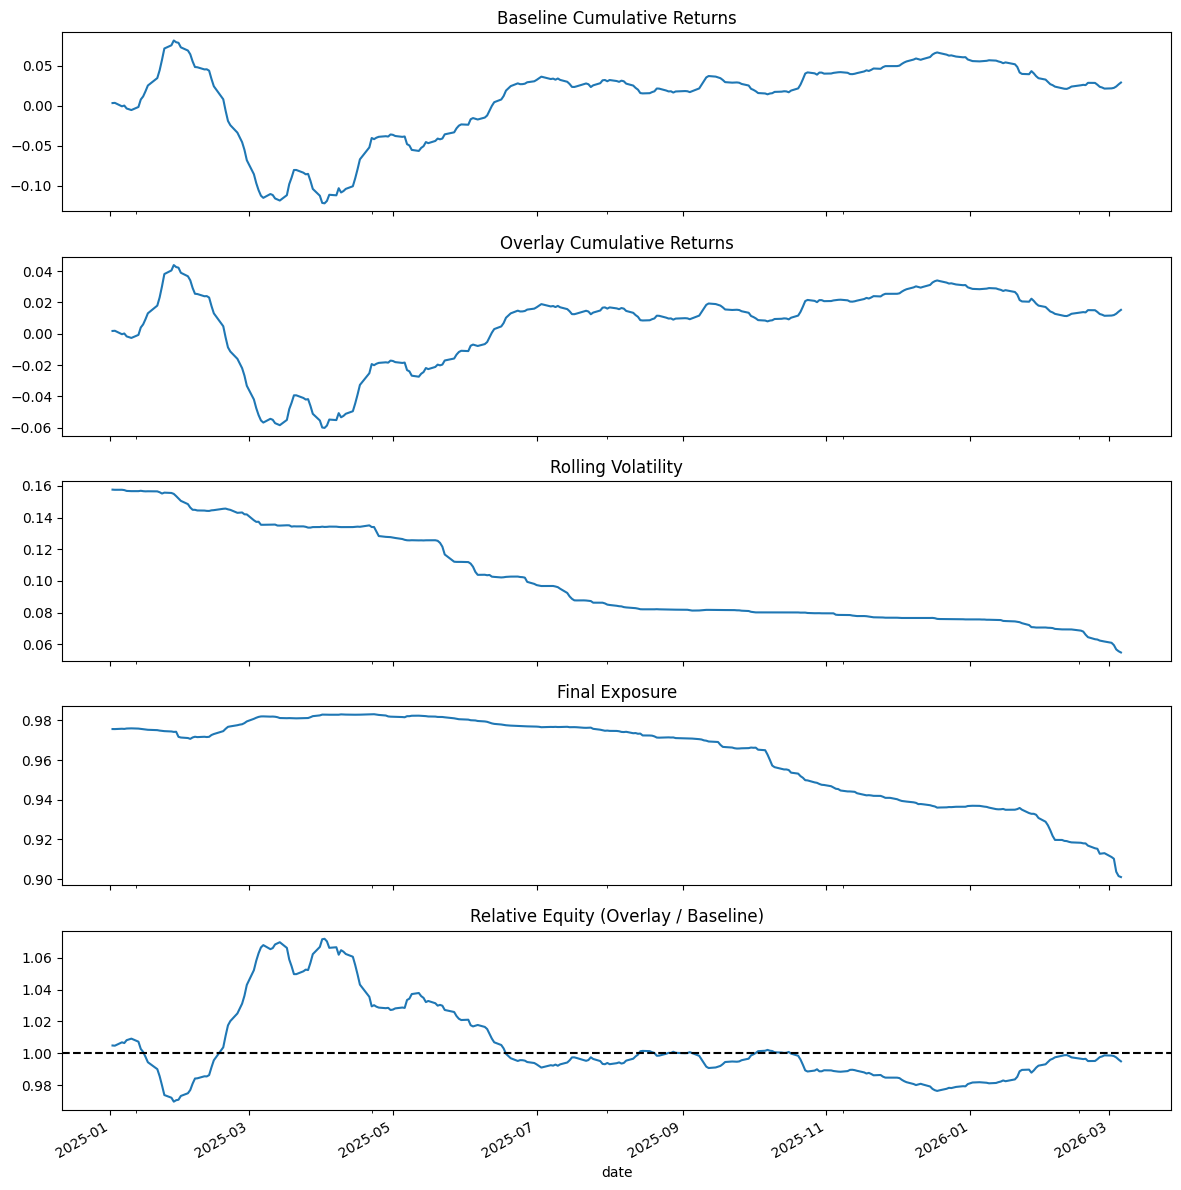

In [45]:
fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 12),
    sharex=True
)

failure_period["baseline_ret"].cumsum().plot(
    ax=axes[0],
    title="Baseline Cumulative Returns"
)

failure_period["combined_ret"].cumsum().plot(
    ax=axes[1],
    title="Overlay Cumulative Returns"
)

failure_period["rolling_vol"].plot(
    ax=axes[2],
    title="Rolling Volatility"
)

failure_period["exposure"].plot(
    ax=axes[3],
    title="Final Exposure"
)

failure_period["relative_equity"].plot(
    ax=axes[4],
    title="Relative Equity (Overlay / Baseline)"
)

axes[4].axhline(
    1.0,
    linestyle="--",
    color="black"
)

plt.tight_layout()
plt.show()

In [46]:
#compare raw returns directly

comparison_recent = pd.DataFrame({
    "baseline": failure_period["baseline_ret"],
    "overlay": failure_period["combined_ret"]
})

comparison_recent.describe()

,baseline,overlay
count,294.000000,294.000000
mean,0.000099,0.000052
std,0.004491,0.002282
min,-0.017422,-0.008711
25%,-0.001627,-0.000813
50%,0.000057,0.000029
75%,0.002018,0.001009
max,0.014934,0.007851


The recent underperformance does not look like catastrophic instability or random collapse. Instead, it appears to be a gradual participation drag caused by the overlay becoming increasingly defensive during a period where realized volatility steadily declined and the baseline strategy itself generated only weak returns. The rolling volatility trended downward throughout 2025–2026, which progressively reduced exposure from roughly 0.98 toward 0.90. As a result, the overlay consistently participated slightly less than the baseline during a shallow but positive market recovery, causing the relative equity curve to drift gradually lower rather than collapse suddenly. Importantly, the overlay still closely tracked the baseline portfolio behavior, and the return distributions remained highly similar, indicating that the adaptive system did not fundamentally destabilize the strategy. This suggests the weakness is more likely due to slow adaptation and mild over-defensiveness in a low-volatility, weak-trend environment rather than structural breakdown of the underlying edge. In other words, the overlay appears to be sacrificing some upside participation while continuing to suppress volatility, which is a far more understandable and potentially fixable issue than an outright loss of strategy coherence.

**Crisis/High Volatility Isolation**

In [50]:
regimes = {
    "COVID Crash": ("2020-02-01", "2020-06-30"),
    "2022 Bear": ("2022-01-01", "2022-12-31"),
    "2023 Recovery": ("2023-01-01", "2023-12-31"),
    "2025 Low Volatility": ("2025-01-01", "2026-03-06")
}

regime_rows = []

for regime_name, (start, end) in regimes.items():

    regime_data = {
        "Baseline": ret.loc[start:end],
        "DD Only": ret_dd_only.loc[start:end],
        "Combined": ret_combined.loc[start:end]
    }

    for strategy_name, strategy_ret in regime_data.items():

        strategy_ret = strategy_ret.dropna()
        strategy_eq = (1 + strategy_ret).cumprod()

        regime_rows.append({
            "Regime": regime_name,
            "Strategy": strategy_name,
            "Sharpe": sharpe_ratio(strategy_ret),
            "MDD": max_drawdown(strategy_eq),
            "CAGR": annualized_return(strategy_ret),
            "Calmar": annualized_return(strategy_ret) / abs(max_drawdown(strategy_eq)),
            "Avg Daily Ret": strategy_ret.mean(),
            "Vol": annualized_volatility(strategy_ret),

        })

regime_df = pd.DataFrame(regime_rows).round(3)

regime_df

,Regime,Strategy,Sharpe,MDD,CAGR,Calmar,Avg Daily Ret,Vol
0,COVID Crash,Baseline,5.898,-0.147,5.200,35.434,0.007,0.319
1,COVID Crash,DD Only,6.129,-0.123,4.261,34.678,0.007,0.278
2,COVID Crash,Combined,6.293,-0.136,4.891,35.884,0.007,0.289
3,2022 Bear,Baseline,3.192,-0.225,0.842,3.742,0.003,0.198
4,2022 Bear,DD Only,3.574,-0.171,0.849,4.968,0.003,0.177
5,2022 Bear,Combined,3.389,-0.191,0.789,4.124,0.002,0.176
6,2023 Recovery,Baseline,3.453,-0.099,0.537,5.428,0.002,0.127
7,2023 Recovery,DD Only,3.406,-0.086,0.409,4.729,0.001,0.102
8,2023 Recovery,Combined,3.418,-0.088,0.421,4.795,0.001,0.105
9,2025 Low Volatility,Baseline,0.350,-0.185,0.023,0.122,0.000,0.071


The crisis and regime-isolation analysis revealed that the adaptive overlay framework behaves in a highly regime-dependent but economically coherent manner. The strategy and overlays performed exceptionally well during turbulent and high-dispersion environments such as the COVID crash and the 2022 bear market, where both the DD-only and combined overlays improved risk-adjusted performance and generally reduced drawdowns relative to the baseline portfolio. During calmer recovery environments such as 2023, the overlays still behaved stably but provided less incremental advantage, suggesting that adaptive defensive controls become less valuable when market conditions normalize. In contrast, all strategies weakened materially during the 2025 low-volatility regime, indicating that the underlying alpha engine itself likely suffered from compressed volatility and reduced market opportunity rather than the overlay causing a structural failure. Importantly, the overlays continued to track the baseline coherently without catastrophic divergence, supporting the view that the framework is structurally stable and primarily acts as an adaptive risk-management layer rather than an artificial performance generator. Although some crisis-period Sharpe ratios appear inflated due to short-horizon annualization effects, the relative behavior across regimes remained highly consistent, reinforcing the interpretation that the system is fundamentally better suited for turbulent, opportunity-rich market environments than compressed low-volatility conditions.

**Different Universe Testing**

In [52]:
ls20 = pd.read_csv(
    PROJECT_ROOT /
    "experiments/completed/exp_004_project04_final/strategy_timeseries/ls_20pct.csv"
)

ls20.head()

,Date,portfolio_return,equity_curve,drawdown
0,0,0.001399,1.001399,0.000000
1,1,0.006374,1.007781,0.000000
2,2,-0.002958,1.004801,-0.002958
3,3,0.001609,1.006418,-0.001353
4,4,-0.006734,0.999641,-0.008078


In [54]:
ret_ls20 = ls20["portfolio_return"]

eq_ls20 = (1 + ret_ls20).cumprod()

dd_ls20 = compute_drawdown(eq_ls20)

#Rolling vol

rolling_vol_ls20 = (
    ret_ls20
    .rolling(252)
    .std()
    * np.sqrt(252)
    )

# vol multiplier
multiplier_ls20 = (
    (rolling_vol_ls20 / rolling_vol_ls20.mean()) ** 0.5
).clip(0.7, 1.3)

dd_exp_ls20 = drawdown_exposure_smooth(
    dd_ls20,
    floor=0.3,
    k=5
)

combined_multiplier_ls20 = (
    multiplier_ls20 * dd_exp_ls20
).clip(0.5, 1.3)


ret_combined_ls20 = apply_exposure_to_return(
    ret_ls20,
    combined_multiplier_ls20
)

eq_combined_ls20 = (
    1 + ret_combined_ls20
).cumprod()

In [55]:
ls20_df = pd.DataFrame([
    {
        "Strategy": "Baseline LS20",
        "Sharpe": sharpe_ratio(ret_ls20),
        "MDD": max_drawdown(eq_ls20),
        "CAGR": annualized_return(ret_ls20),
        "Calmar": annualized_return(ret_ls20) / abs(max_drawdown(eq_ls20)),
    },

    {
        "Strategy": "Overlay LS20",
        "Sharpe": sharpe_ratio(ret_combined_ls20),
        "MDD": max_drawdown(eq_combined_ls20),
        "CAGR": annualized_return(ret_combined_ls20),
        "Calmar": annualized_return(ret_combined_ls20) / abs(max_drawdown(eq_combined_ls20)),
    }

]).round(3)

ls20_df

,Strategy,Sharpe,MDD,CAGR,Calmar
0,Baseline LS20,1.516,-0.655,0.425,0.648
1,Overlay LS20,2.040,-0.436,0.450,1.032


The different-universe portability test provided one of the strongest robustness signals observed in the project so far. Applying the same adaptive DD-overlay framework to the independent LS20 strategy stream from Project 04 resulted in substantial improvements across nearly all key portfolio metrics, including Sharpe ratio, maximum drawdown, CAGR, and Calmar ratio. Most notably, the overlay reduced the extremely deep baseline drawdown from approximately -65% to -44% while simultaneously improving long-term compounding, suggesting that the overlay may be selectively suppressing disproportionately harmful portfolio periods rather than merely reducing exposure indiscriminately. Importantly, the adaptive behavior remained economically coherent and structurally stable despite being applied to a materially different strategy path, which significantly reduces concerns that the overlay improvement is merely an artifact of the specific Project 05 return stream. While this does not fully prove universal robustness or deployment readiness, the portability of the DD-overlay behavior across distinct strategy architectures provides meaningful evidence that the adaptive risk-control mechanism may capture a broader structural effect rather than relying on narrow in-sample optimization.

**Turnover Analysis**

In [56]:
turnover = combined_multiplier.diff().abs()
turnover.describe()

count    2.054000e+03
mean     1.153883e-03
std      2.140540e-03
min      7.028280e-08
25%      1.714733e-04
50%      5.229983e-04
75%      1.301678e-03
max      4.015661e-02
Name: returns, dtype: float64

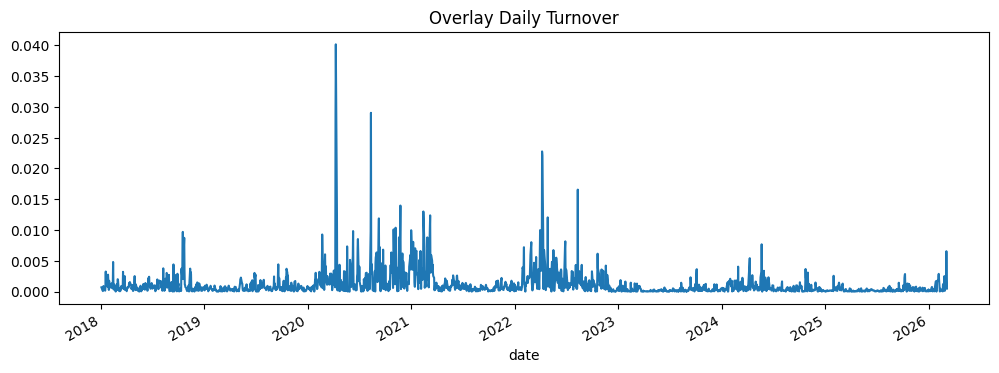

In [57]:
turnover.plot(figsize=(12,4), title="Overlay Daily Turnover")
plt.show()

The turnover analysis revealed that the adaptive overlay framework adjusts portfolio exposure in a remarkably smooth and stable manner, with extremely low average daily turnover and only occasional spikes during major stress or regime-transition periods. Since turnover measures the absolute day-to-day change in portfolio exposure, these results suggest that the overlay is not behaving like a hyperactive or noisy trading system but rather as a slow-moving adaptive risk-control mechanism. Most daily adjustments were extremely small, indicating that the overlay is not constantly rebalancing in response to minor fluctuations, which substantially reduces concerns regarding excessive transaction costs or unrealistic implementation assumptions. Importantly, the largest turnover spikes occurred primarily during turbulent environments such as 2020, which is economically coherent because those are precisely the periods where adaptive exposure changes would be expected to become more active. Overall, the turnover behavior strongly supports the interpretation that the overlay framework is operationally stable and structurally realistic rather than dependent on excessively frequent trading or fragile short-term reactions.

**Transaction Cost Stress Test**